In this notebook I will perform bivariate analysis to better understand the relationship between the columns of the dataframe 

### import dataframe

In [1]:
import pandas as pd
import os 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

raw_data = pd.read_parquet("../data/bronze/clean_dataset.parquet",  engine='pyarrow')
raw_data = raw_data.sort_values(["date", "time"]).reset_index(drop=True)
raw_data.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.900002,99.0,37.980000,Cash,0.0
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.100000,114.0,39.290001,Uber Wallet,0.0
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,NaN,1.0
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,NaN,1.0
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,NaN,1.0


In [2]:
data = raw_data.copy()
data['datetime'] = pd.to_datetime(data['date'] + " " + data['time'], format="%Y-%m-%d %H:%M:%S")

# since there is a clear pattern seen in "time" I create "hour"
data['hour'] = data['datetime'].dt.hour


# remove features that were discovered to be leaking in 04_univar_eda
leaking_cols = ["avg_ctat",	"booking_value","ride_distance","payment_method"]

data.drop(columns= leaking_cols, inplace= True)

# add binned avg_vtat
bins = [0, 5, 10, 15, 20]
labels = ["0-5", "5–10", "10–15", "15–20"]

data["avgvtat_bins"] = pd.cut( data["avg_vtat"], bins=bins,labels=labels).astype("category")
data.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,is_cancelled,datetime,hour,avgvtat_bins
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,0.0,2024-01-01 00:19:34,0,10–15
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,0.0,2024-01-01 01:35:18,1,5–10
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,1.0,2024-01-01 01:37:50,1,5–10
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,1.0,2024-01-01 01:48:03,1,5–10
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,1.0,2024-01-01 01:49:56,1,5–10


### hour

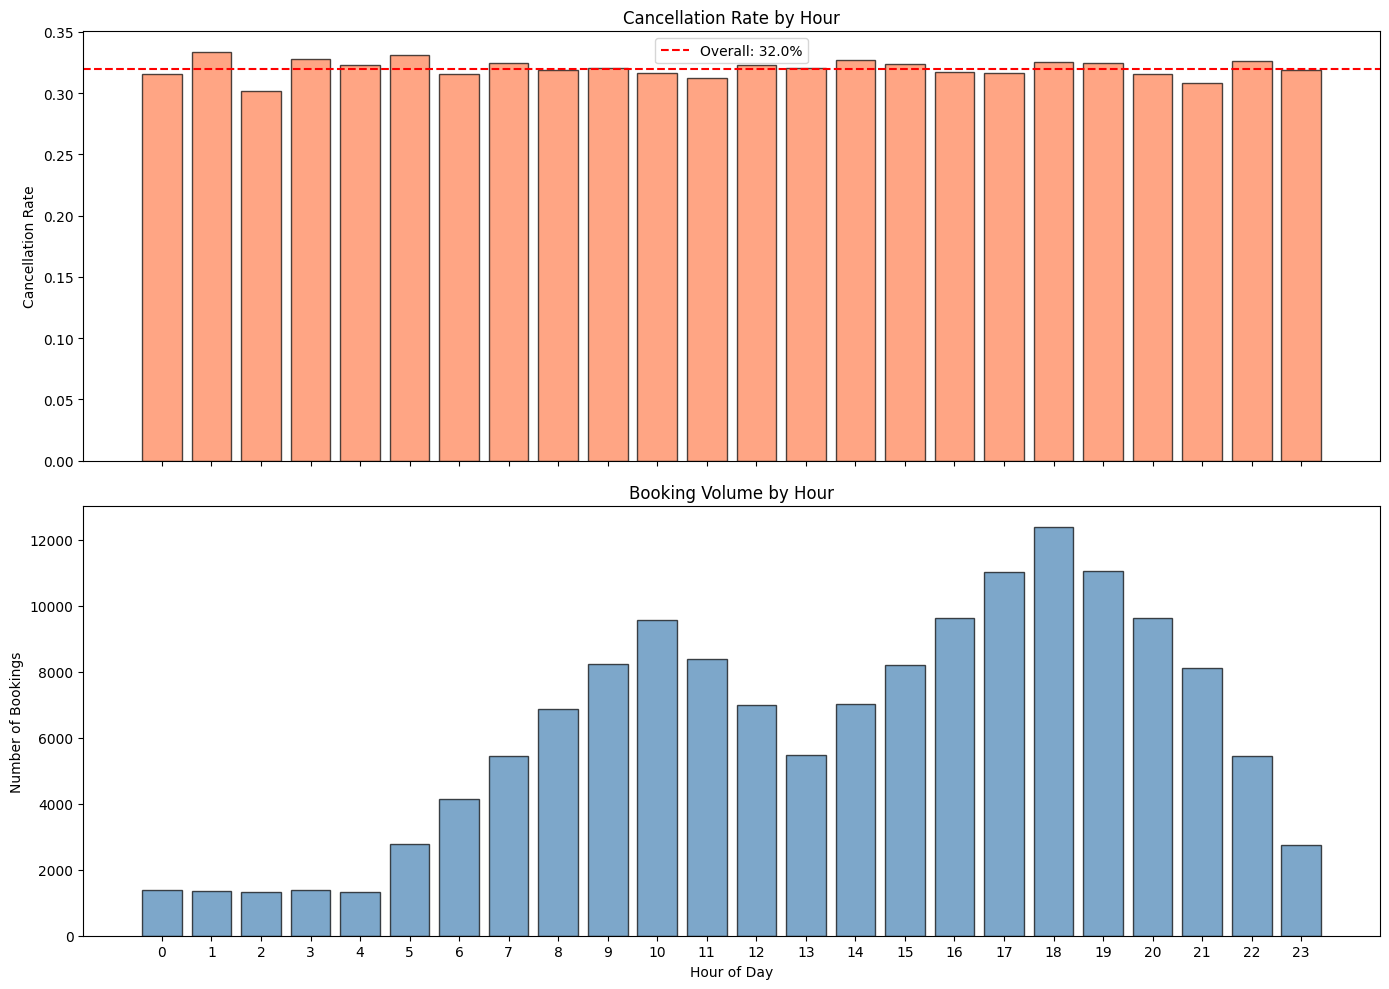

In [3]:
df = data.copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Hourly cancellation rate
ax1 = axes[0]
hourly_rate = df.groupby('hour')['is_cancelled'].mean()
hourly_count = df.groupby('hour')['is_cancelled'].count()

ax1.bar(hourly_rate.index, hourly_rate.values,
        color='coral', edgecolor='black', alpha=0.7)

ax1.axhline(
    y=df['is_cancelled'].mean(),
    color='red',
    linestyle='--',
    label=f'Overall: {df["is_cancelled"].mean():.1%}'
)

ax1.set_ylabel('Cancellation Rate')
ax1.set_title('Cancellation Rate by Hour')
ax1.legend()
ax1.set_xticks(range(0, 24))

# Hourly booking volume
ax2 = axes[1]
ax2.bar(hourly_count.index, hourly_count.values,
        color='steelblue', edgecolor='black', alpha=0.7)

ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Number of Bookings')
ax2.set_title('Booking Volume by Hour')
ax2.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()


Cancellation rate is remarkably flat across hours and the hour-to-hour variation is small. Hour of day alone is a weak marginal predictor of cancellation because there is no "danger hour" where cancellations could spike.

Booking volume per hour shows that clear daily pattern where morning and afternoon have peaks but not because they are riskier, but because that's where the volume is.

### booking_id

In [4]:
# let's check the behaviour of cancellations within duplicated booking_id rows. 
# How many cancellations happen because there was a mistake in the platform? (same )

In [5]:
counts_bookings = data["booking_id"].value_counts()
ids_duplicated_twice = counts_bookings[counts_bookings == 2].index
ids_duplicated_twice

Index(['CNR3023930', 'CNR8540413', 'CNR9671362', 'CNR9538874', 'CNR4006852',
       'CNR3058894', 'CNR2690212', 'CNR1507993', 'CNR8505153', 'CNR9095547',
       ...
       'CNR4121915', 'CNR6770460', 'CNR2705928', 'CNR5969212', 'CNR6472828',
       'CNR9073729', 'CNR9515739', 'CNR2809735', 'CNR9246603', 'CNR1776813'],
      dtype='string', name='booking_id', length=1215)

In [ ]:
duplicates_twice = data[data["booking_id"].isin(ids_duplicated_twice)].sort_values(["booking_id", "datetime"])
print(f" There are {len(duplicates_twice)} rows with 'booking_id' duplicated")
duplicates_twice.head(4)

 There are 2430 rows with 'booking_id' duplicated


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,is_cancelled,datetime,hour,avgvtat_bins
83526,2024-07-21,17:59:41,CNR1026036,CID6974869,Go Mini,Seelampur,Nehru Place,NaN,1.0,2024-07-21 17:59:41,17,NaN
118826,2024-10-15,18:17:23,CNR1026036,CID6480133,Go Mini,Khandsa,Ashok Vihar,3.8,0.0,2024-10-15 18:17:23,18,0-5
7709,2024-01-19,17:00:57,CNR1029172,CID2615731,Bike,Jhilmil,Narsinghpur,4.7,0.0,2024-01-19 17:00:57,17,0-5
144662,2024-12-17,19:19:02,CNR1029172,CID6382731,Auto,Inderlok,Laxmi Nagar,6.9,0.0,2024-12-17 19:19:02,19,5–10


In [13]:
cancel_summary = (duplicates_twice.groupby("booking_id")["is_cancelled"].agg(list))

cancel_df = pd.DataFrame(cancel_summary.tolist(), index=cancel_summary.index, columns=["first_is_cancelled", "second_is_cancelled"])
transition = cancel_summary.apply(
    lambda x: f"{int(x[0])}{int(x[1])}"
)

# 4. One-row contingency table
contingency_1row = (
    transition
    .value_counts()
    .reindex(["00", "01", "10", "11"], fill_value=0)
    .to_frame()
    .T
)
print(f" Contingency table with duplicated bookings where 0 = not cancelled and 1 = cancelled")
contingency_1row

 Contingency table with duplicated bookings where 0 = not cancelled and 1 = cancelled


is_cancelled,00,01,10,11
count,532,265,287,131


Is [1.0, 0.0] duplicated because there was an error in the system and the first ride was cancelled? Let's check the datetime for that. If both datetimes are close then it means the user performed some cancellation and this behaviour should be studied further. 

Is [1.0, 1.0] consecutive? could it mean fraud? 



In [8]:
first_cancelled_second_no = cancel_summary[cancel_summary.apply(lambda x: x == [1, 0])]
first_cancelled_second_no_rows = duplicates_twice[duplicates_twice["booking_id"].isin(first_cancelled_second_no.index)].sort_values(["booking_id", "datetime"])
print(f" There are {len(first_cancelled_second_no_rows)} rows where the same booking id was first cancelled and then accepted")

first_cancelled_second_no_rows.head(10)

 There are 574 rows where the same booking id was first cancelled and then accepted


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,is_cancelled,datetime,hour,avgvtat_bins
83526,2024-07-21,17:59:41,CNR1026036,CID6974869,Go Mini,Seelampur,Nehru Place,NaN,1.0,2024-07-21 17:59:41,17,NaN
118826,2024-10-15,18:17:23,CNR1026036,CID6480133,Go Mini,Khandsa,Ashok Vihar,3.8,0.0,2024-10-15 18:17:23,18,0-5
17756,2024-02-12,19:02:47,CNR1058956,CID2451799,Premier Sedan,Patel Chowk,Kaushambi,19.9,1.0,2024-02-12 19:02:47,19,15–20
118724,2024-10-15,13:33:55,CNR1058956,CID1882606,Go Mini,Badshahpur,MG Road,3.7,0.0,2024-10-15 13:33:55,13,0-5
76446,2024-07-04,15:46:39,CNR1091682,CID1131593,Go Mini,Vishwavidyalaya,Botanical Garden,13.7,1.0,2024-07-04 15:46:39,15,10–15
92873,2024-08-13,10:39:17,CNR1091682,CID1590844,eBike,Punjabi Bagh,Khan Market,7.4,0.0,2024-08-13 10:39:17,10,5–10
12389,2024-01-30,20:38:35,CNR1129818,CID8993312,Bike,Civil Lines Gurgaon,Manesar,3.4,1.0,2024-01-30 20:38:35,20,0-5
13399,2024-02-02,10:53:00,CNR1129818,CID9692280,Bike,Greater Kailash,Ramesh Nagar,12.3,0.0,2024-02-02 10:53:00,10,10–15
71217,2024-06-22,05:06:13,CNR1130025,CID5686876,Auto,Subhash Nagar,Kaushambi,4.6,1.0,2024-06-22 05:06:13,5,0-5
132082,2024-11-17,12:20:34,CNR1130025,CID4646812,Bike,Gurgaon Sector 29,Kanhaiya Nagar,9.9,0.0,2024-11-17 12:20:34,12,5–10


I don't see consecutive datetimes and users, I really don't understand why Uber is recycling booking_ids

is there a pattern in the duplicated rows where both have been cancelled?

In [15]:
both_cancelled = cancel_summary[cancel_summary.apply(lambda x: x == [1.0, 1.0])]
both_cancelled_rows = duplicates_twice[duplicates_twice["booking_id"].isin(both_cancelled.index)].sort_values(["booking_id", "datetime"])
print(f" There are {len(both_cancelled_rows)} rows where the same booking id was first cancelled and then accepted")

both_cancelled_rows.head(10)

 There are 262 rows where the same booking id was first cancelled and then accepted


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,is_cancelled,datetime,hour,avgvtat_bins
86249,2024-07-28,02:06:31,CNR1125525,CID5846635,eBike,Nehru Place,Sohna Road,8.8,1.0,2024-07-28 02:06:31,2,5–10
107509,2024-09-18,10:08:25,CNR1125525,CID1702916,Auto,Seelampur,Chhatarpur,8.6,1.0,2024-09-18 10:08:25,10,5–10
72850,2024-06-26,05:50:14,CNR1156110,CID9436591,Go Mini,Qutub Minar,Huda City Centre,NaN,1.0,2024-06-26 05:50:14,5,NaN
85522,2024-07-26,11:40:42,CNR1156110,CID6894365,Premier Sedan,Jor Bagh,Welcome,15.7,1.0,2024-07-26 11:40:42,11,15–20
40581,2024-04-08,12:16:53,CNR1179739,CID4465093,Premier Sedan,Jor Bagh,Sonipat,8.3,1.0,2024-04-08 12:16:53,12,5–10
46597,2024-04-23,09:16:10,CNR1179739,CID8468490,Go Sedan,Jahangirpuri,Udyog Vihar Phase 4,NaN,1.0,2024-04-23 09:16:10,9,NaN
43937,2024-04-16,15:49:30,CNR1205744,CID5537003,eBike,Sushant Lok,Noida Sector 18,7.5,1.0,2024-04-16 15:49:30,15,5–10
144160,2024-12-16,16:45:13,CNR1205744,CID6734392,Go Sedan,Yamuna Bank,Jahangirpuri,3.6,1.0,2024-12-16 16:45:13,16,0-5
9355,2024-01-23,16:18:30,CNR1275970,CID9601488,Premier Sedan,Karol Bagh,Govindpuri,4.6,1.0,2024-01-23 16:18:30,16,0-5
29646,2024-03-12,20:59:04,CNR1275970,CID9047745,Premier Sedan,Hauz Rani,Bahadurgarh,11.0,1.0,2024-03-12 20:59:04,20,10–15


My hypothesis was wrong. Same booking_id belongs to different customers and is used in different datetimes. That is a clear misuse of identifiers and can lead to errors and poor performance

In [18]:
ids_triplicated = counts_bookings[counts_bookings == 3].index
ids_triplicated

Index(['CNR2726142', 'CNR7642097', 'CNR5292943', 'CNR6337479', 'CNR7908610',
       'CNR9603232', 'CNR7585544', 'CNR3648267', 'CNR7199036'],
      dtype='string', name='booking_id')

In [19]:
duplicates_thrice = data[data["booking_id"].isin(ids_triplicated)].sort_values(["booking_id", "datetime"])
print(f" There are {len(duplicates_thrice)} rows with 'booking_id' duplicated")
duplicates_thrice.head(4)

 There are 27 rows with 'booking_id' duplicated


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,is_cancelled,datetime,hour,avgvtat_bins
58520,2024-05-22,10:58:23,CNR2726142,CID6203511,Go Mini,Chanakyapuri,Sultanpur,7.9,0.0,2024-05-22 10:58:23,10,5–10
69768,2024-06-18,14:38:50,CNR2726142,CID9496782,Go Sedan,Madipur,Panchsheel Park,8.9,0.0,2024-06-18 14:38:50,14,5–10
106506,2024-09-15,20:51:23,CNR2726142,CID7293070,Premier Sedan,Sadar Bazar Gurgaon,Laxmi Nagar,2.1,0.0,2024-09-15 20:51:23,20,0-5
67504,2024-06-13,04:26:17,CNR3648267,CID1753108,Auto,Yamuna Bank,Ashram,13.6,0.0,2024-06-13 04:26:17,4,10–15


In [20]:
cancel_summary_three = (duplicates_thrice.groupby("booking_id")["is_cancelled"].agg(list))
cancel_summary_three

booking_id
CNR2726142    [0.0, 0.0, 0.0]
CNR3648267    [0.0, 0.0, 0.0]
CNR5292943    [0.0, 0.0, 0.0]
CNR6337479    [0.0, 0.0, 0.0]
CNR7199036    [0.0, 0.0, 0.0]
CNR7585544    [0.0, 0.0, 0.0]
CNR7642097    [1.0, 0.0, 0.0]
CNR7908610    [0.0, 0.0, 0.0]
CNR9603232    [0.0, 1.0, 0.0]
Name: is_cancelled, dtype: object

There is not enough data to extract any clear pattern here